In [9]:
import numpy as np
import cv2
from glob import glob
import matplotlib.pyplot as plt

In [10]:
fpath = glob('./data/female/*.jpg') #returns all images path in a list
mpath = glob('./data/male/*.jpg')   #returns all images path in a list

In [11]:
print('Number of images in Female folder = ', len(fpath))
print('Number of images in Male folder = ', len(mpath))

Number of images in Female folder =  4762
Number of images in Male folder =  5399


### Step 1 - Read all images and convet them to RGB

In [12]:
img = cv2.imread(fpath[0]) # read image in BGR format
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # convert from BGR to RGB

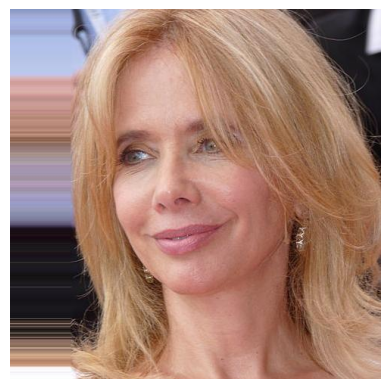

In [13]:
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

### Step 2 Apply Haar Cascade Classifier

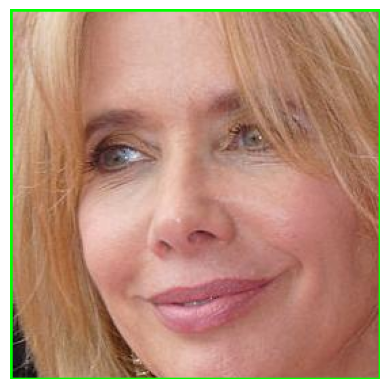

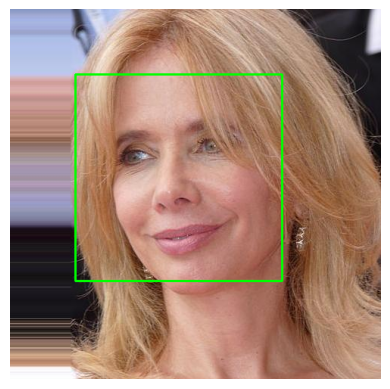

In [14]:
haar = cv2.CascadeClassifier('./model/haarcascade_frontalface_default.xml')
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
face_list = haar.detectMultiScale(gray, 1.5, 5)

for x,y,w,h in face_list:
    cv2.rectangle(img_rgb, (x,y), (x+w, y+h), (0, 255, 0), 2)
    ### Step 3 - Crop Face
    roi = img_rgb[y:y+h, x:x+w]
    plt.imshow(roi)
    plt.axis('off')
    plt.show()

plt.imshow(img_rgb)
plt.axis('off')
plt.show()

### Crop all female images

In [17]:
for i in range(len(fpath)):
    try:
        img = cv2.imread(fpath[i]) # read image in BGR format
        if img is None:
            print(f"Error: Could not read image at {fpath[i]}")
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # convert from BGR to RGB
        gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        face_list = haar.detectMultiScale(gray, 1.5, 5)
        
        for x,y,w,h in face_list:
            ### Step 3 - Crop Face
            roi = img[y:y+h, x:x+w] # Extract face region of interest (ROI)
            # Step 4 Safe Image
            cv2.imwrite(f'./data/crop_data/female/female_{i}.jpg', roi)
    except FileNotFoundError:
        print(f"Error: File not found at index {i}")
    except cv2.error as e:
        print(f"Error: OpenCV error at index {i}: {e}")
    except Exception as e:
        print(f"Error: Unexpected error at index {i}: {e}")


### Crop all male images

In [18]:
for i in range(len(mpath)):
    try:
        img = cv2.imread(mpath[i]) # read image in BGR format
        if img is None:
            print(f"Error: Could not read image at {mpath[i]}")
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # convert from BGR to RGB
        gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        face_list = haar.detectMultiScale(gray, 1.5, 5)
        
        for x,y,w,h in face_list:
            ### Step 3 - Crop Face
            roi = img[y:y+h, x:x+w] # Extract face region of interest (ROI)
            # Step 4 Safe Image
            cv2.imwrite(f'./data/crop_data/male/male_{i}.jpg', roi)
    except FileNotFoundError:
        print(f"Error: File not found at index {i}")
    except cv2.error as e:
        print(f"Error: OpenCV error at index {i}: {e}")
    except Exception as e:
        print(f"Error: Unexpected error at index {i}: {e}")
